In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle, warnings
import numpy as np
import pandas as pd

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import (SPE1_PICKLE_ROOT, DICT_CELL_TYPE, DICT_PATCH_TYPE,
                    DICT_CORT_DEPTH, DICT_DARK_NEURONS, DICT_EAP_WAV)
from pop_ridge_utils import load_population_results, aggregate_population, run_r2_tests
from pop_metadata_utils import (
    build_metadata_df,
    plot_cell_sig_heatmap,
    plot_r2_by_group,
    plot_alpha_by_group,
    plot_metadata_vs_mean_r2,
    plot_n_spikes_confound,
    plot_duration_rate_vs_metadata,
    run_beta_metadata_analysis,
    plot_predictor_set_comparison,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

In [ ]:
# ── Run-control flags ───────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


# Population metadata analysis — spe-1

Characterise which cells and which cell properties drive the population-level
waveform → LFP predictability found in `pop_ridge_regression.ipynb`.

**Questions addressed**

| § | Question |
|---|---|
| 1 | Which cells have significant models, and for which targets? |
| 2 | Do CV R² and regularisation strength vary across LFP target groups? |
| 3 | Does cell identity (type, depth, dark-neuron) predict mean R²? |
| 4 | Is n_spikes a confound — driven by firing rate or recording length? |
| 5 | Are recording duration and firing rate unevenly distributed across cell metadata groups? |
| 6 | For R²-significant targets, does cell metadata explain *directionality* of beta weights? |
| 7 | Does adding log-ISI to waveform features improve prediction? |

In [2]:
# ── Load ridge regression results ─────────────────────────────────────────────
RIDGE_PICKLE_DIR = os.path.join(SPE1_PICKLE_ROOT, 'ridge_regression_pickles')

all_results, cell_ids, target_names, predictor_sets = load_population_results(RIDGE_PICKLE_DIR)

feat_labels   = FEAT_LABELS
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Post {l}'    for l in feat_labels] +
    [f'Post−BL {l}' for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

# Load population summary pickle
pop_path = os.path.join(RIDGE_PICKLE_DIR, 'population_ridge_results.pkl')
with open(pop_path, 'rb') as f:
    pop = pickle.load(f)

r2_pop        = pop['r2_pop']
sig_pop       = pop['sig_pop']
beta_pop      = pop['beta_pop']
df_tests      = pop['df_tests']
mean_beta_mat = pop['mean_beta_mat']
sig_beta_mat  = pop['sig_beta_mat']

# Load or recompute df_r2 (Wilcoxon median R²>0 population test)
df_r2 = pop.get('df_r2', None)
if df_r2 is None:
    print('df_r2 not in pickle — recomputing …')
    r2_tmp, sig_tmp, _ = aggregate_population(all_results, cell_ids, target_names, predictor_sets)
    df_r2 = run_r2_tests(r2_tmp, target_names, target_labels, predictor_sets)
    print(f'  → {df_r2.sig_r2.sum()} significant targets')
else:
    print(f'Loaded df_r2: {len(df_r2)} rows  |  {df_r2.sig_r2.sum()} significant')

print(f'\n{len(cell_ids)} cells  |  {len(target_names)} targets')

Loaded 37 cells  |  25 targets  |  3 predictor sets
Loaded df_r2: 75 rows  |  6 significant

37 cells  |  25 targets


In [3]:
# ── Compute firing rate and recording duration from spike times ───────────────
import glob
dict_firing_rate   = {}
dict_rec_duration  = {}

for pkl_path in sorted(glob.glob(
        os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', 'c*_cluster_df.pkl'))):
    cnum = int(os.path.basename(pkl_path).replace('_cluster_df.pkl', '').lstrip('c'))
    with open(pkl_path, 'rb') as f:
        cdf = pickle.load(f)
    t_ms = cdf['spk_times_ms'].values
    dur_s = (t_ms.max() - t_ms.min()) / 1000.0
    dict_firing_rate[cnum]  = len(t_ms) / dur_s          # Hz
    dict_rec_duration[cnum] = dur_s / 60.0                # minutes

# ── Build metadata DataFrame ──────────────────────────────────────────────────
df = build_metadata_df(
    all_results, cell_ids, target_names, target_labels, predictor_sets,
    DICT_CELL_TYPE, DICT_PATCH_TYPE, DICT_CORT_DEPTH, DICT_DARK_NEURONS, DICT_EAP_WAV,
    dict_firing_rate=dict_firing_rate,
    dict_rec_duration=dict_rec_duration,
)
print(df[['cell_id', 'cell_type', 'n_spikes', 'firing_rate_hz',
          'rec_duration_min', 'n_sig_waveform_only', 'mean_r2_wv']].to_string(index=False))

cell_id cell_type  n_spikes  firing_rate_hz  rec_duration_min  n_sig_waveform_only  mean_r2_wv
    c10        PC      1055        2.635041          6.736137                    7   -0.001346
    c12        IN      7367        4.554104         26.997629                   16    0.006737
    c13        PC      3515        4.357694         13.489549                    0   -0.002199
    c14        PC      6085        5.651548         17.992121                    7   -0.000448
    c15        PC      3180        2.953549         17.950157                   18    0.013566
    c16        IN      9915       14.743226         11.249234                   20    0.005144
    c19        PC      7443        9.226931         13.496723                   12    0.001233
     c1        PC      1672        6.541630          4.349069                    2   -0.000748
    c20        PC       363        0.912353          6.649476                    4   -0.007797
    c21        PC     12552       11.651701       

## Setup: per-cell metadata DataFrame

One row per cell. Columns:
- **Cell biology**: cell type (PC/IN), cortical depth, dark-neuron status
- **Recording properties**: patch type (juxtacellular/whole-cell), EAP visibility
- **Ridge regression stats**: mean R², n significant targets, per-target R²/significance/alpha

Firing rate (Hz) and recording duration (min) computed from spike times in cluster pickles.

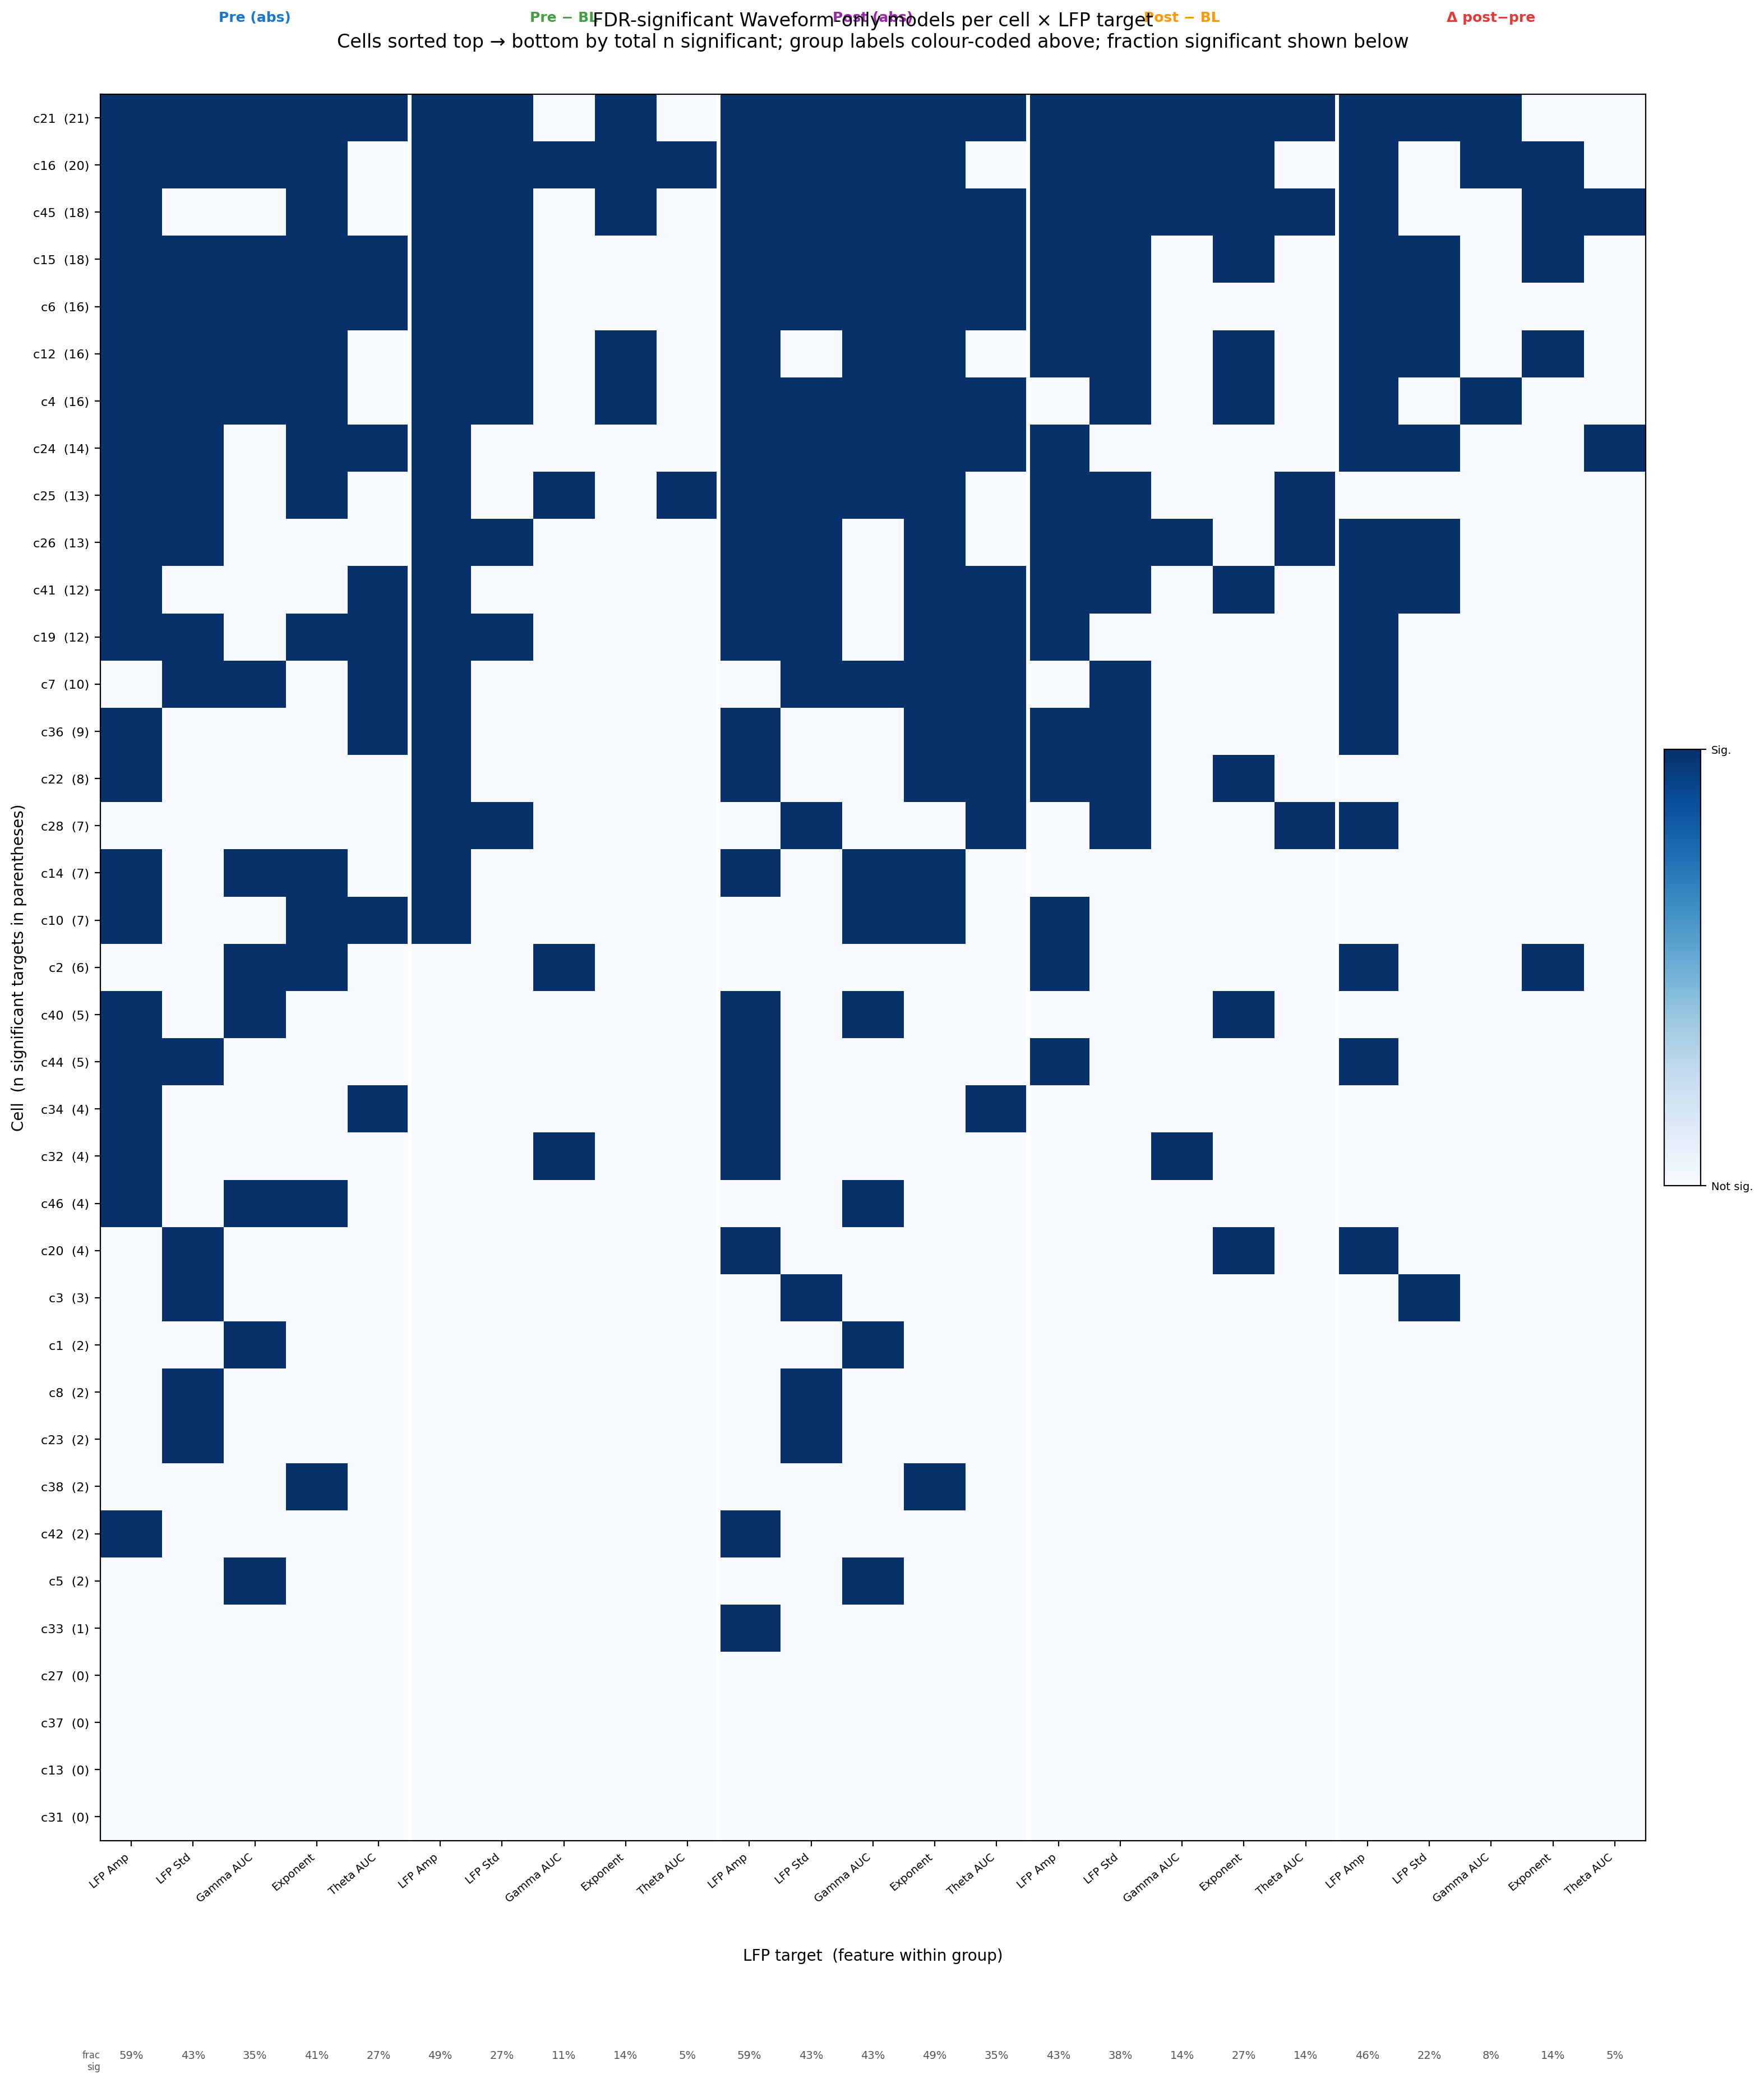

Cells with ≥1 significant target: 33/37
Targets with ≥1 significant cell: 25/25


In [4]:
plot_cell_sig_heatmap(df, cell_ids, target_names, target_labels)

## 1. Cell × target significance heatmap

Which cells have significant Waveform-only models, and for which LFP targets?
Cells sorted by total n significant targets. Fraction significant per target shown below x-axis.

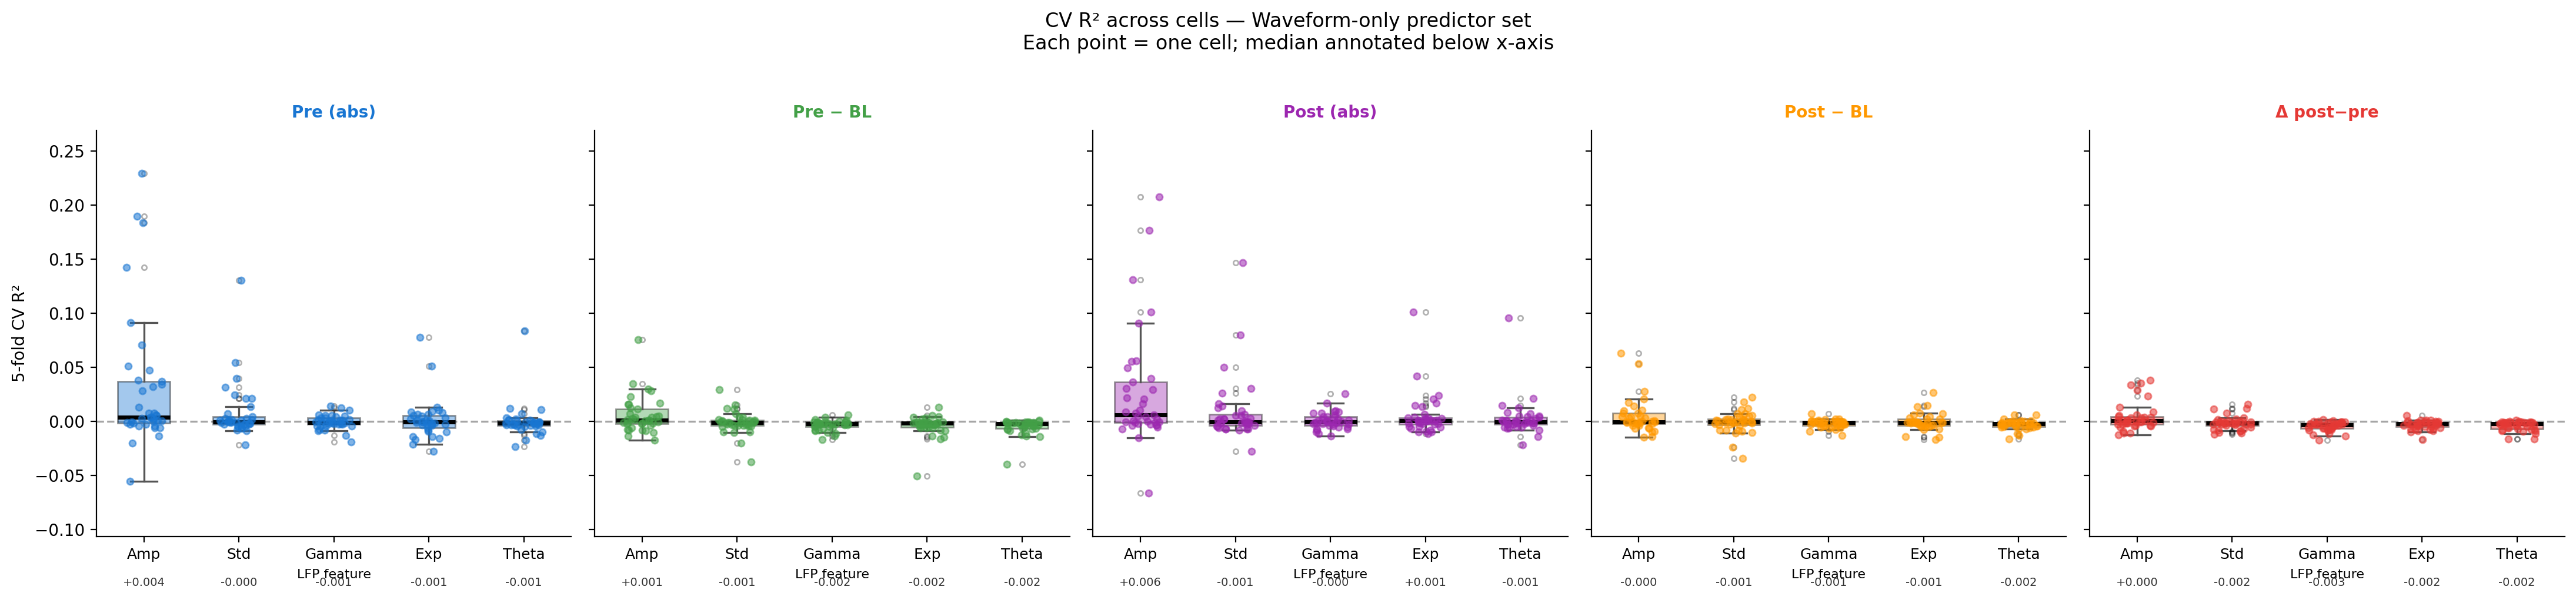

In [5]:
plot_r2_by_group(df, target_names, feat_labels)

## 2. CV R² and regularisation strength by target group

Do R² and regularisation vary across LFP target groups?

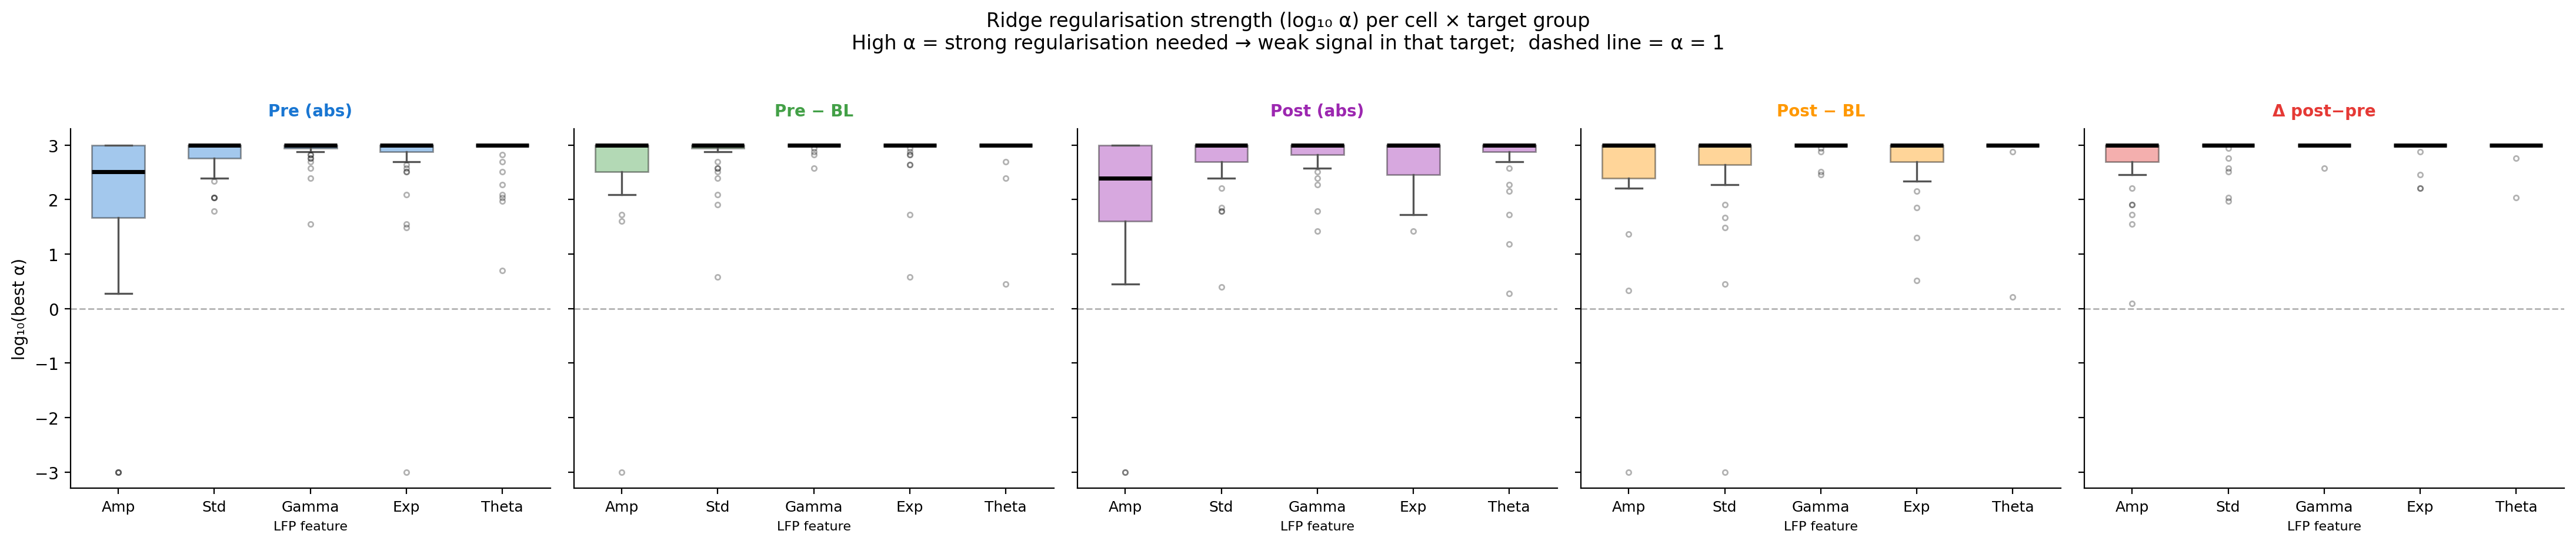

In [6]:
plot_alpha_by_group(df, target_names, feat_labels)

Best Ridge alpha (log₁₀) selected by cross-validation per cell. High alpha = stronger regularisation selected for that target.

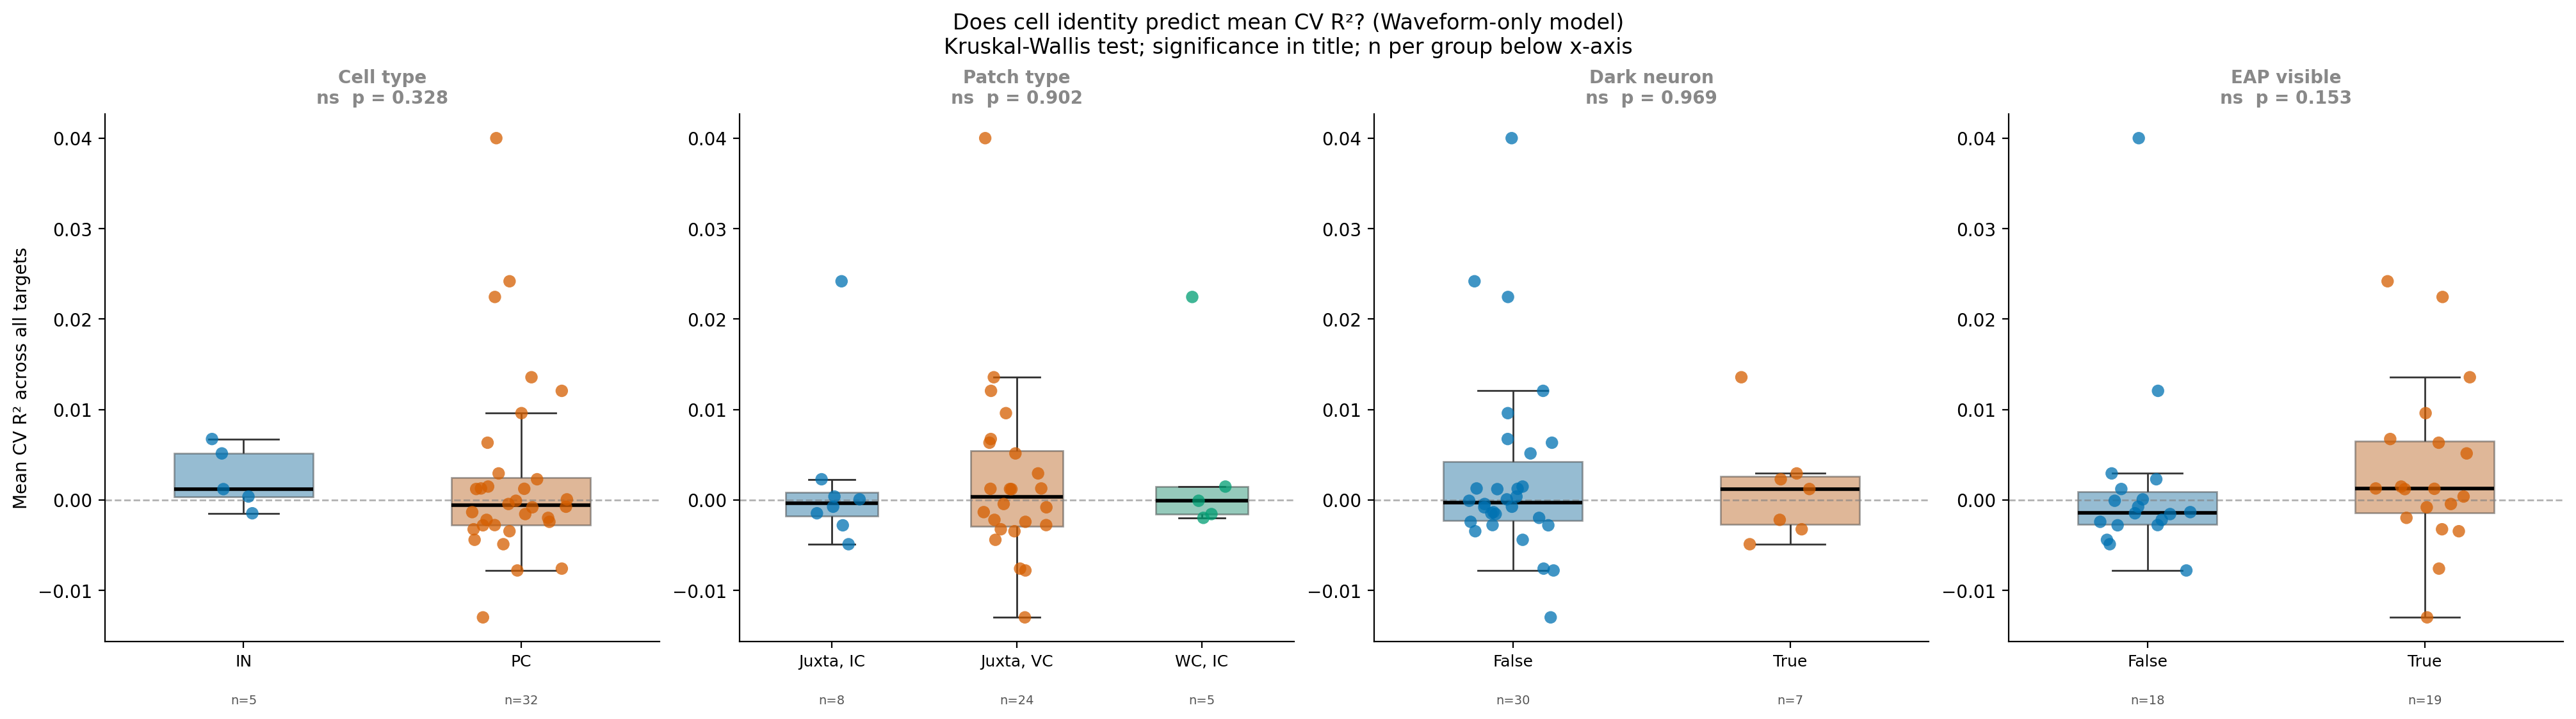

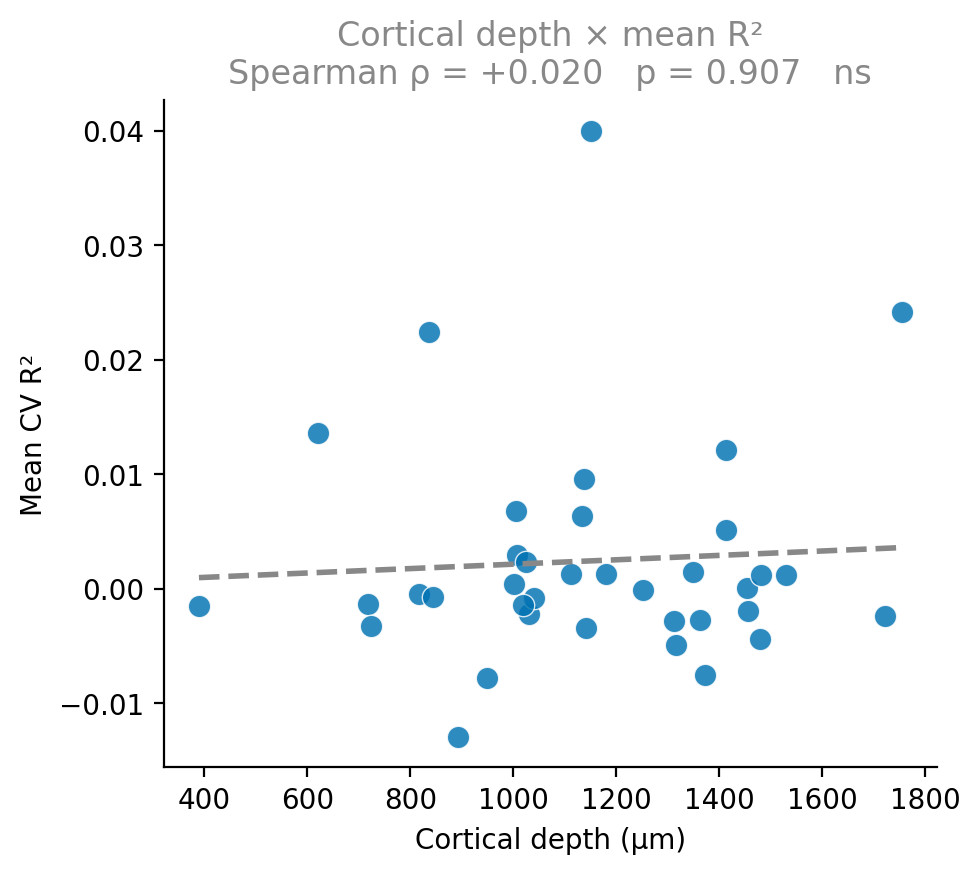

In [7]:
plot_metadata_vs_mean_r2(df)

## 3. Does cell identity predict mean R²?

Categorical variables (cell type, patch type, dark-neuron, EAP visibility): Kruskal-Wallis.
Continuous variable (cortical depth): Spearman ρ.

n_spikes              rho=+0.519  p=0.001  ***  ⚠  potential confound
firing_rate_hz        rho=+0.321  p=0.053  ns  ✓  not a confound
rec_duration_min      rho=+0.398  p=0.015  *  ⚠  potential confound


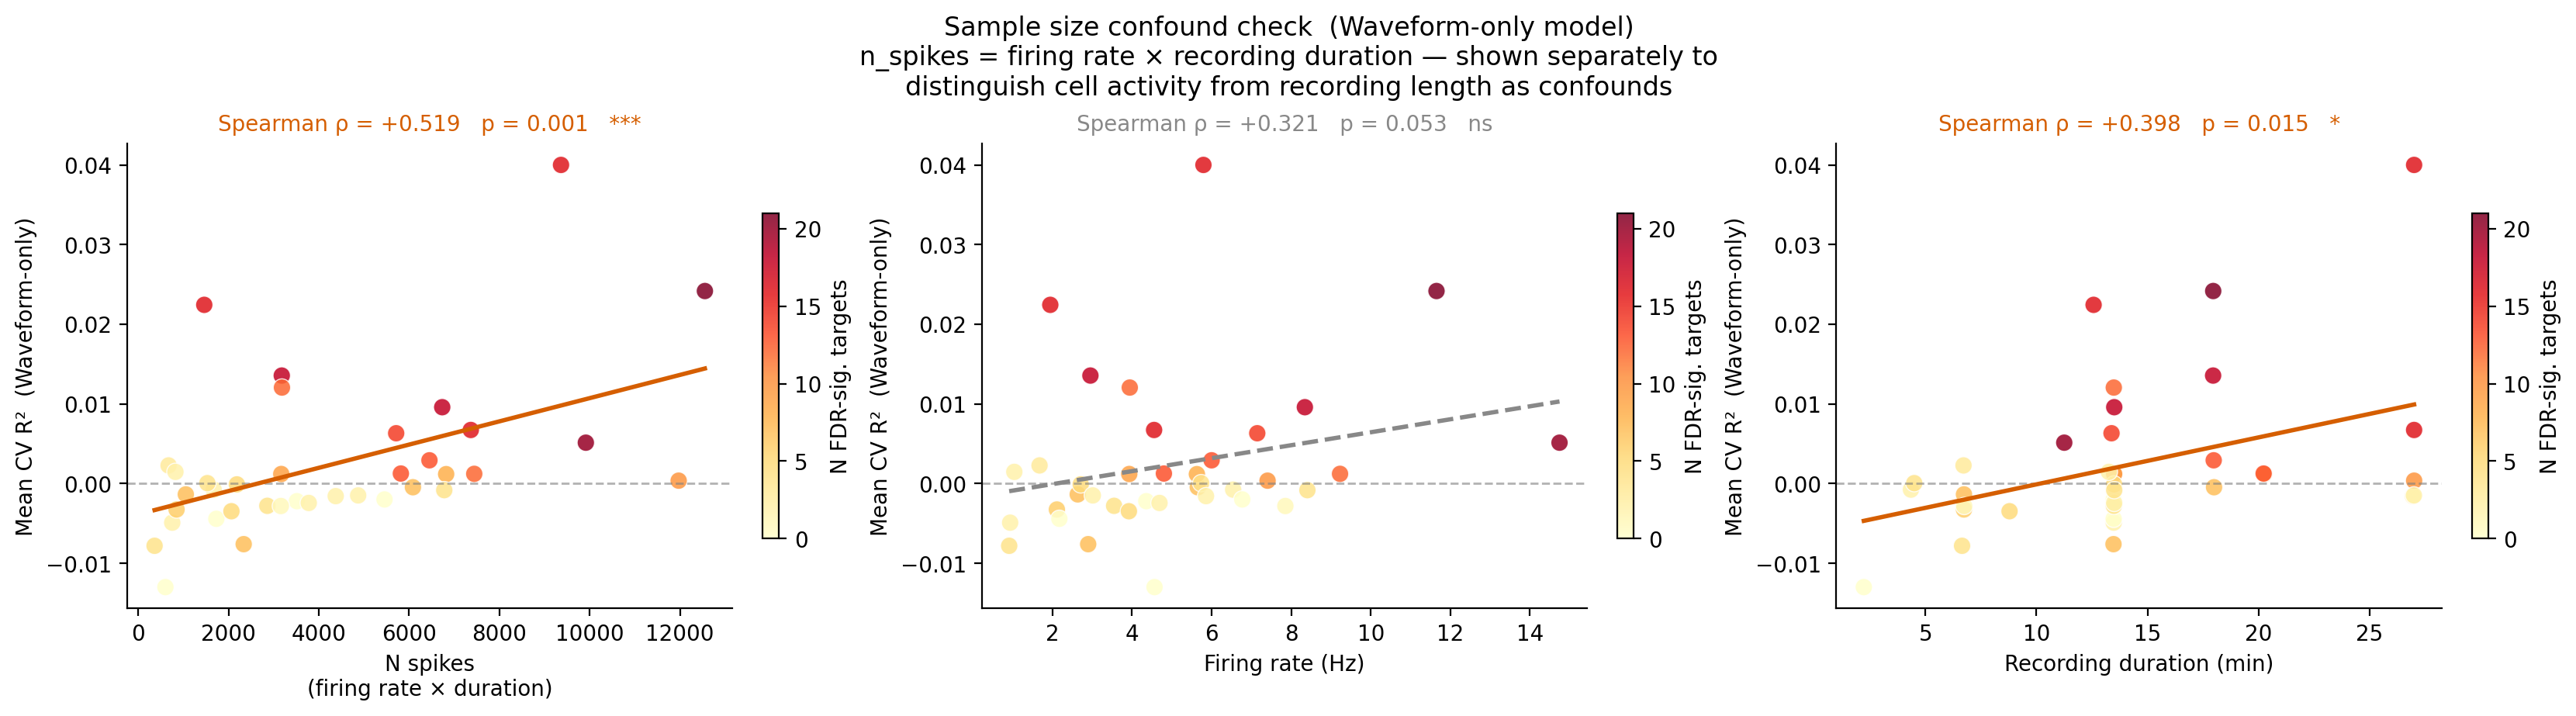

In [8]:
plot_n_spikes_confound(df)

## 4. Is n_spikes a confound?

`n_spikes = firing_rate × recording_duration`. Three panels separate the two components to identify which (if either) drives any n_spikes–R² association.

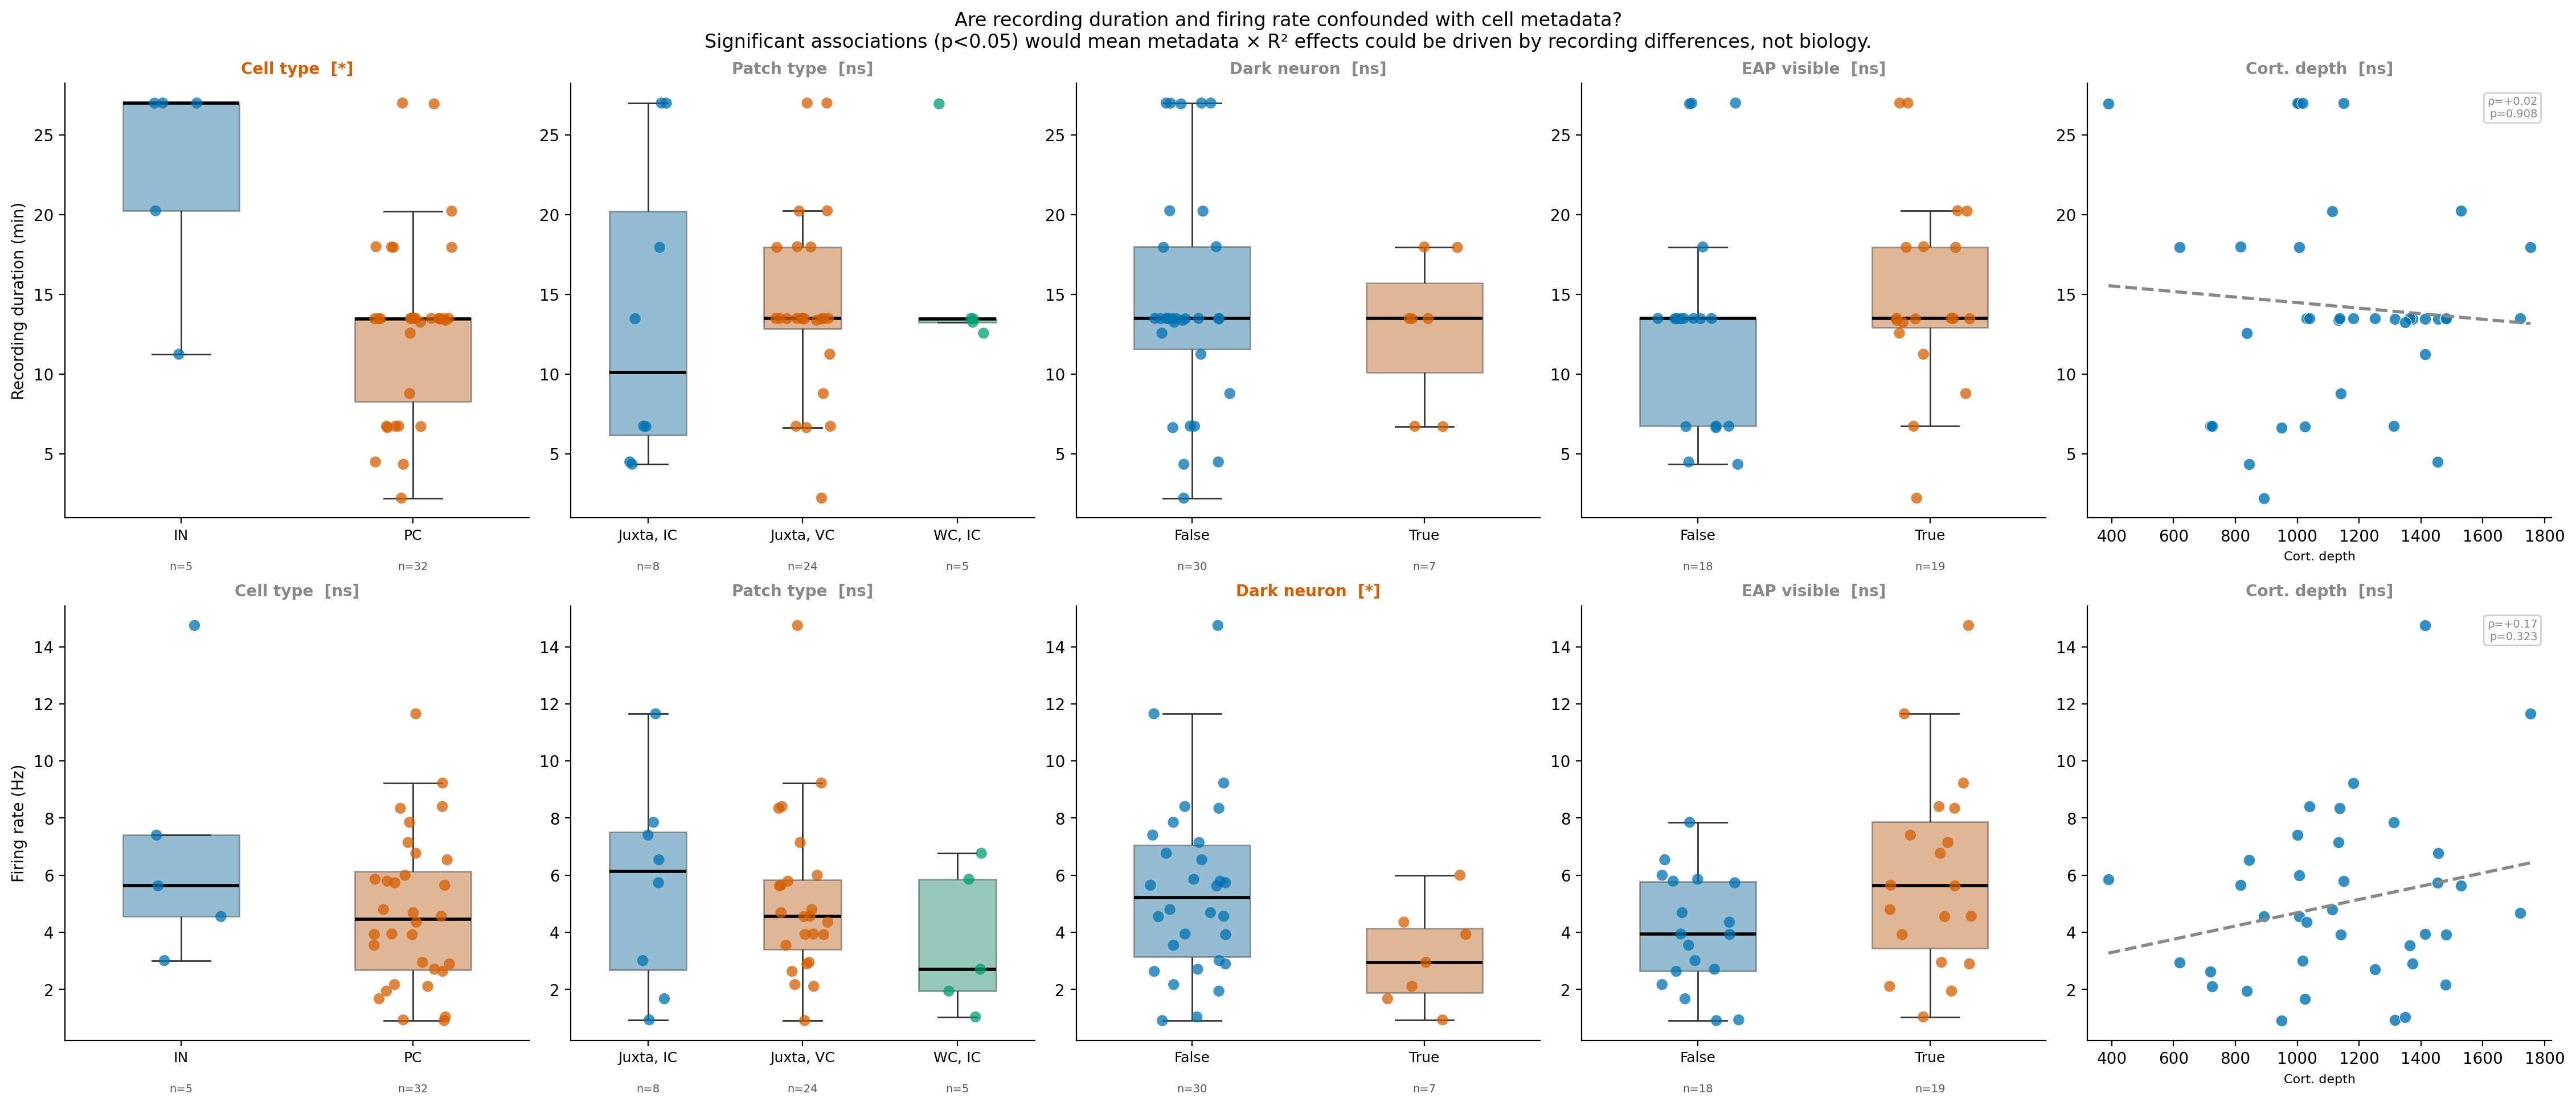

In [9]:
plot_duration_rate_vs_metadata(df)

## 5. Are recording duration and firing rate unevenly distributed across cell metadata groups?

A duration difference by patch type (juxta vs WC) would be methodological. A difference by cell type or cortical depth would be biologically meaningful but could still affect interpretation of §3 — if INs are recorded for shorter periods, PC vs IN R² differences could partly reflect recording length. Orange = p < 0.05 uncorrected.

2 R²-significant Waveform-only targets:
target_label  median_r2  mean_r2  p_wilcox_fdr
 Pre LFP Amp   0.003837 0.029959      0.040807
Post LFP Amp   0.005738 0.026820      0.026802



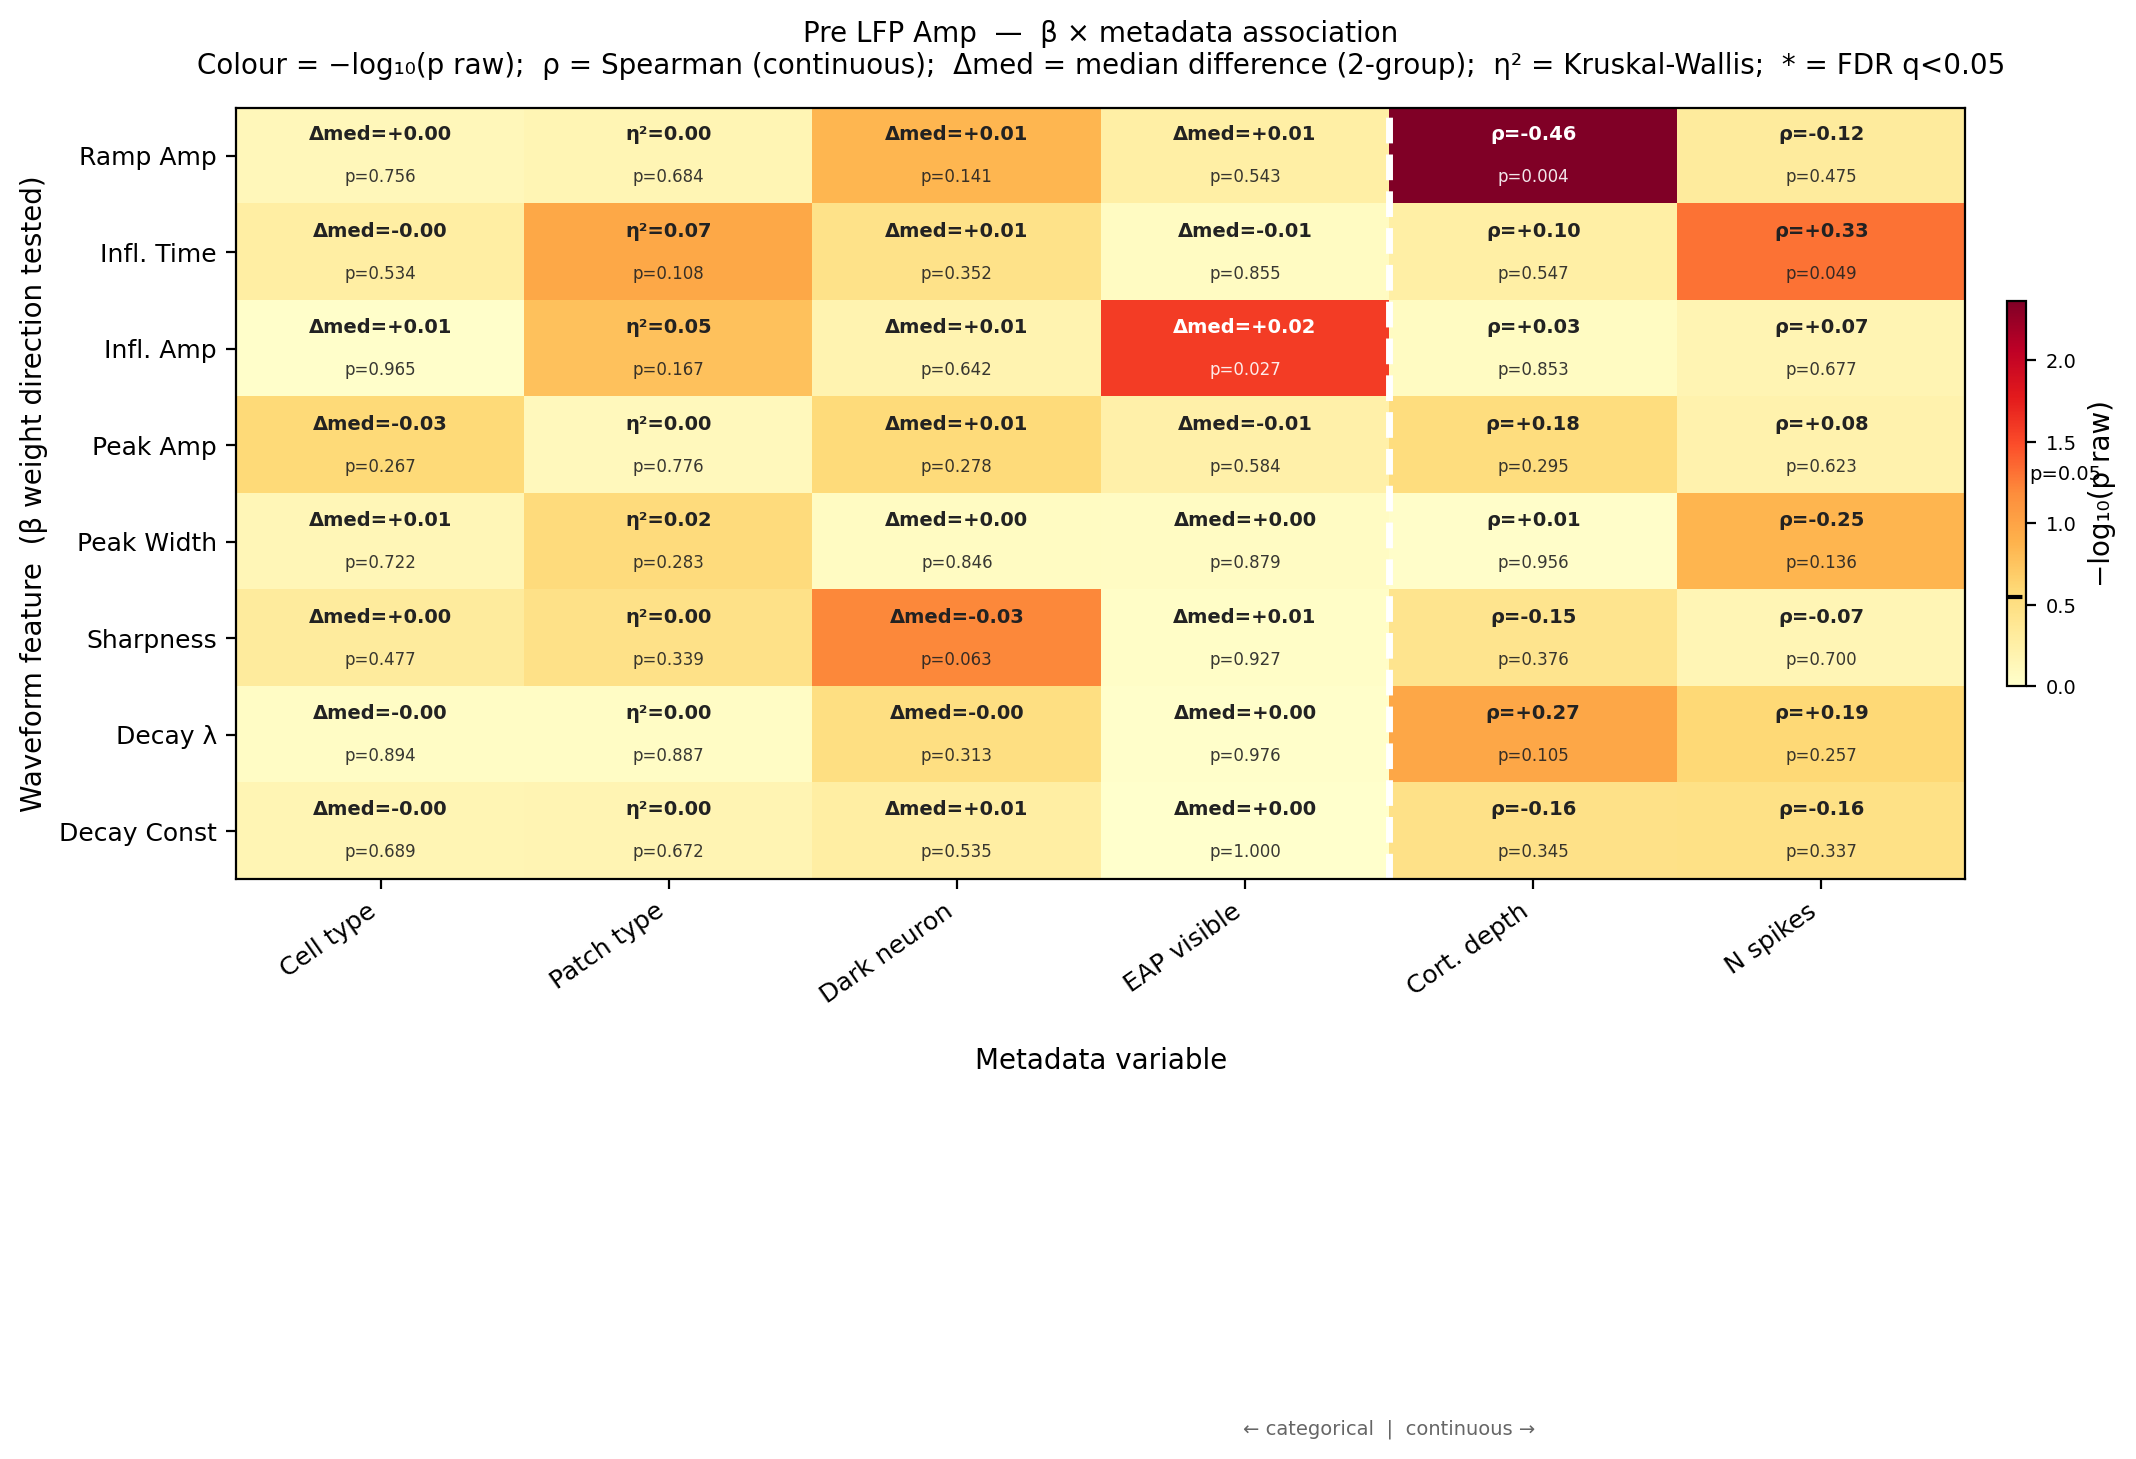

  Pre LFP Amp:  FDR-sig = 0  |  nominally sig (p<0.05) = 3  |  showing top 6 by raw p

  Feature           Metadata            Effect    p-raw    FDR q  sig
  ─────────────────────────────────────────────────────────────────
  Ramp Amp          Cort. depth       ρ = -0.459   0.0043   0.2061  **
  Infl. Amp         EAP visible     Δmed = +0.019   0.0265   0.6369  *
  Infl. Time        N spikes          ρ = +0.326   0.0491   0.7523  *
  Sharpness         Dark neuron     Δmed = -0.034   0.0627   0.7523  ns
  Decay λ           Cort. depth       ρ = +0.271   0.1047   0.8436  ns
  Infl. Time        Patch type        η² = 0.072   0.1083   0.8436  ns



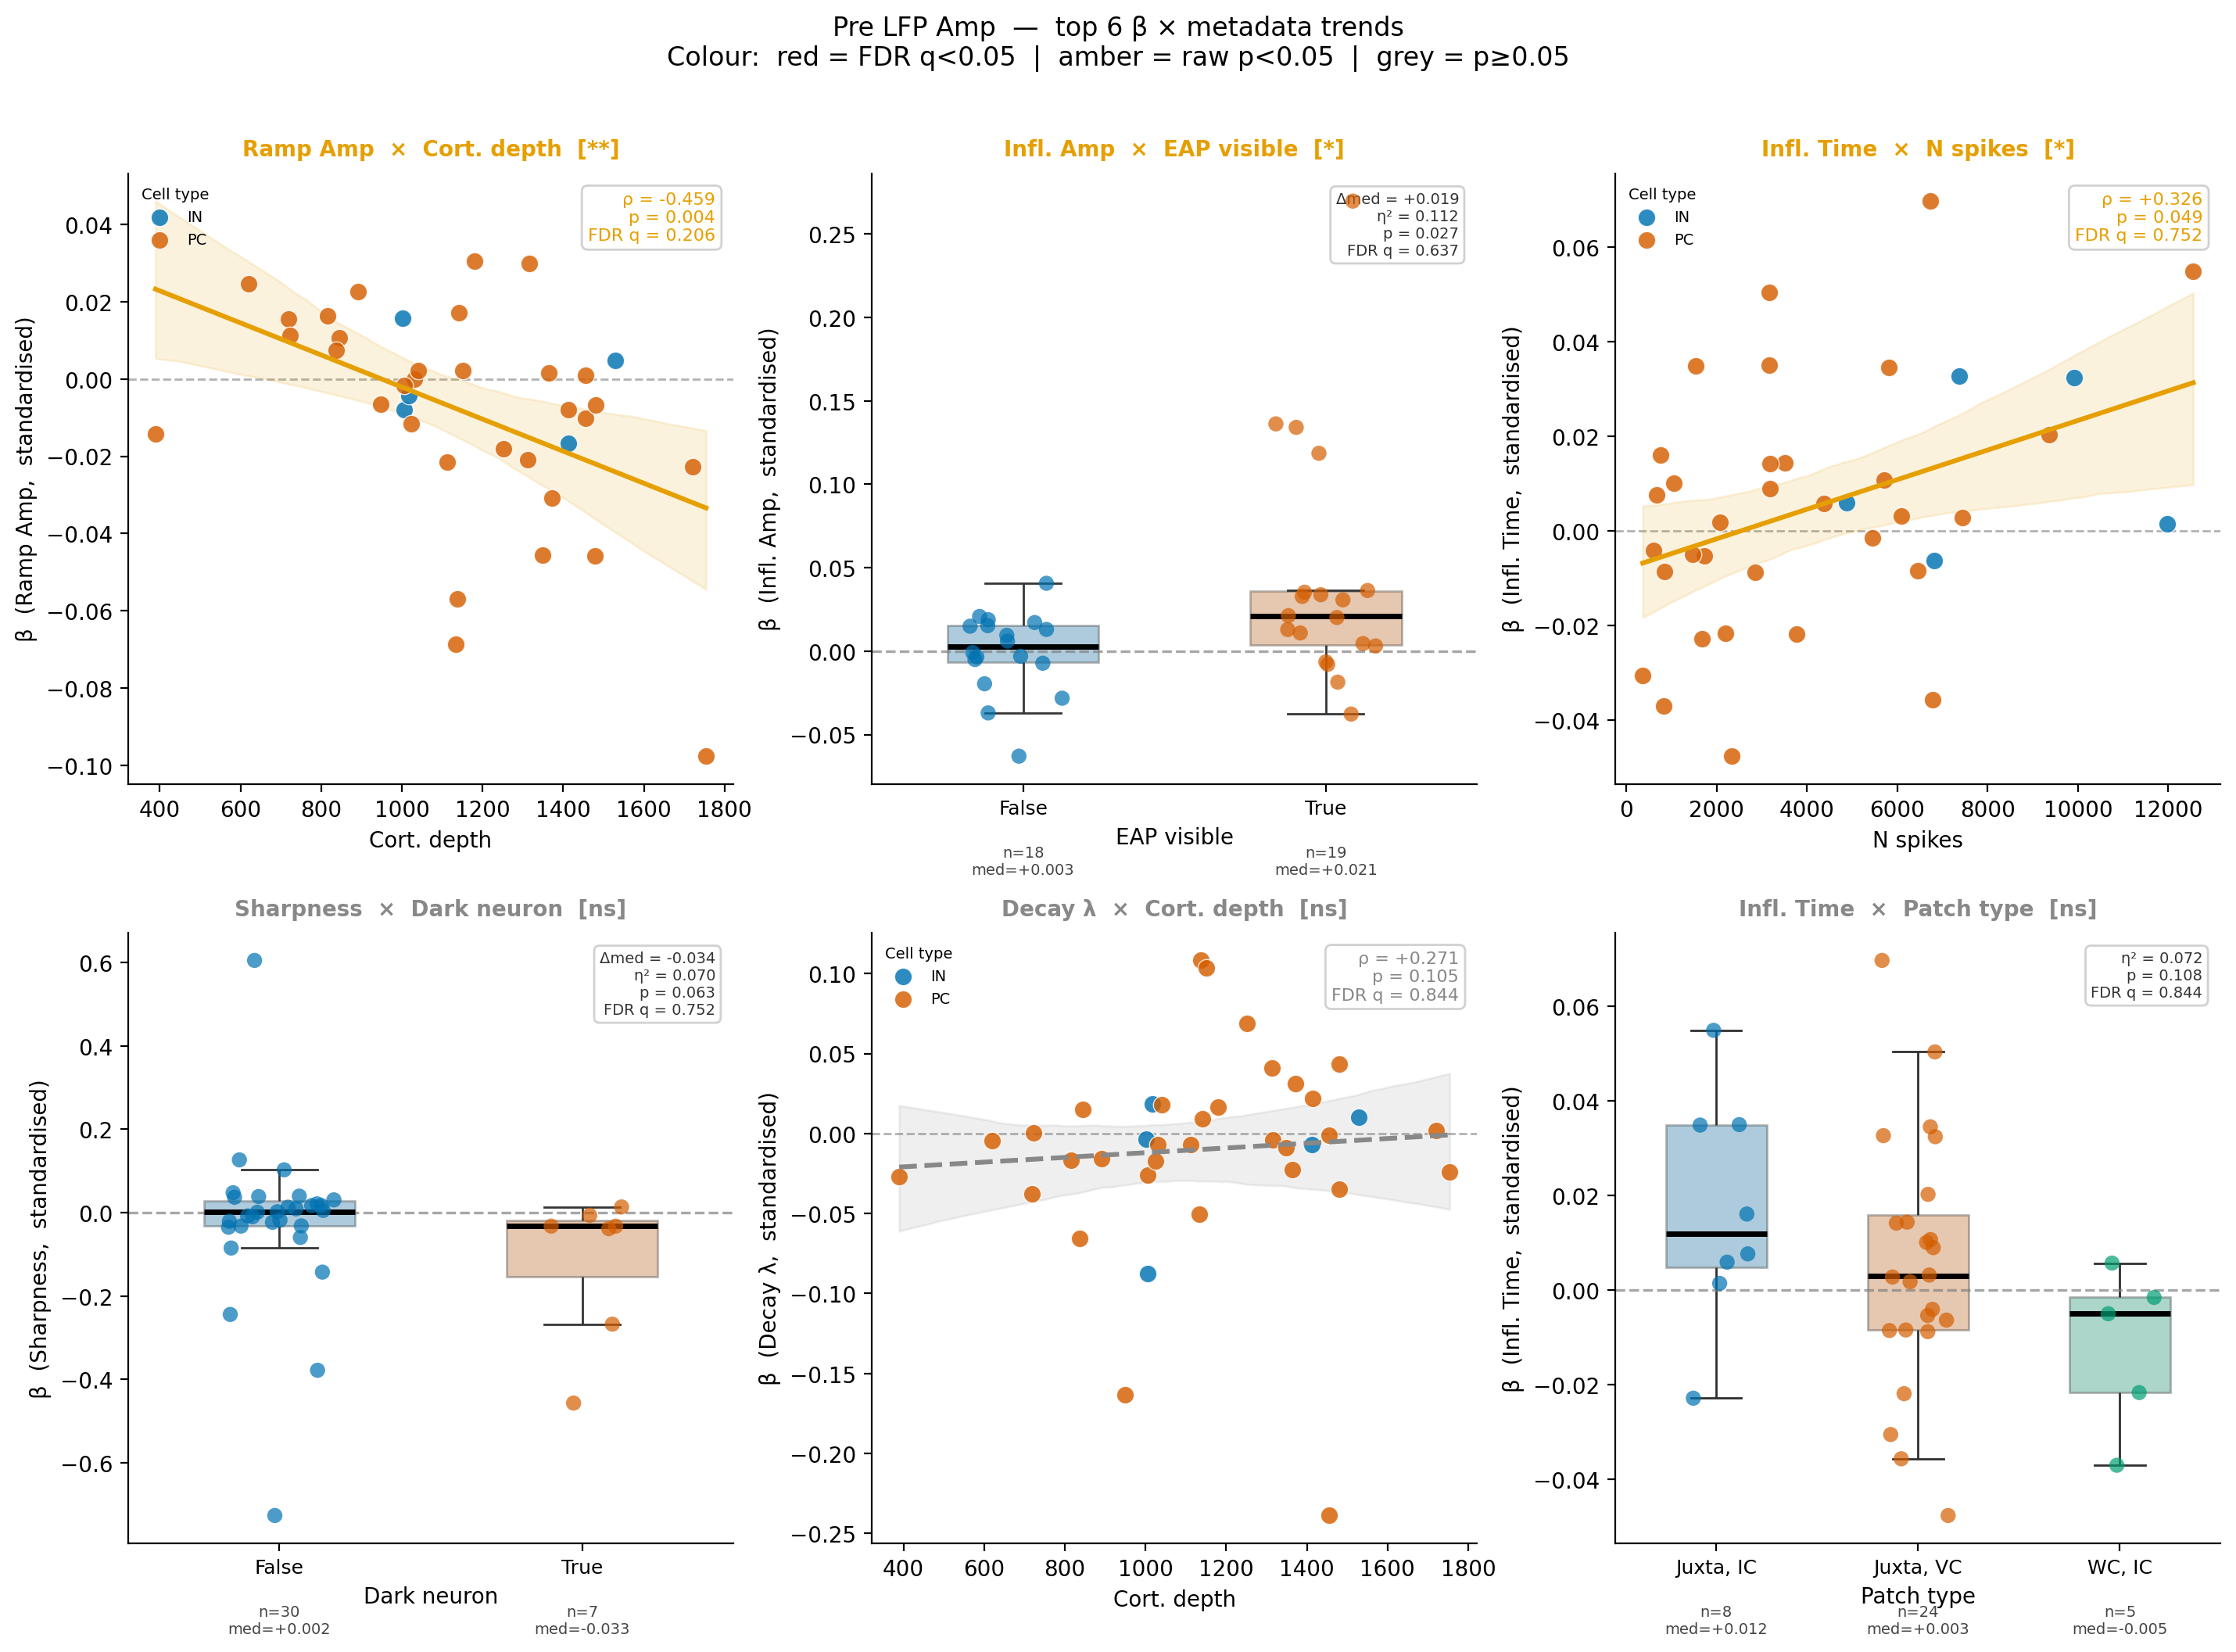

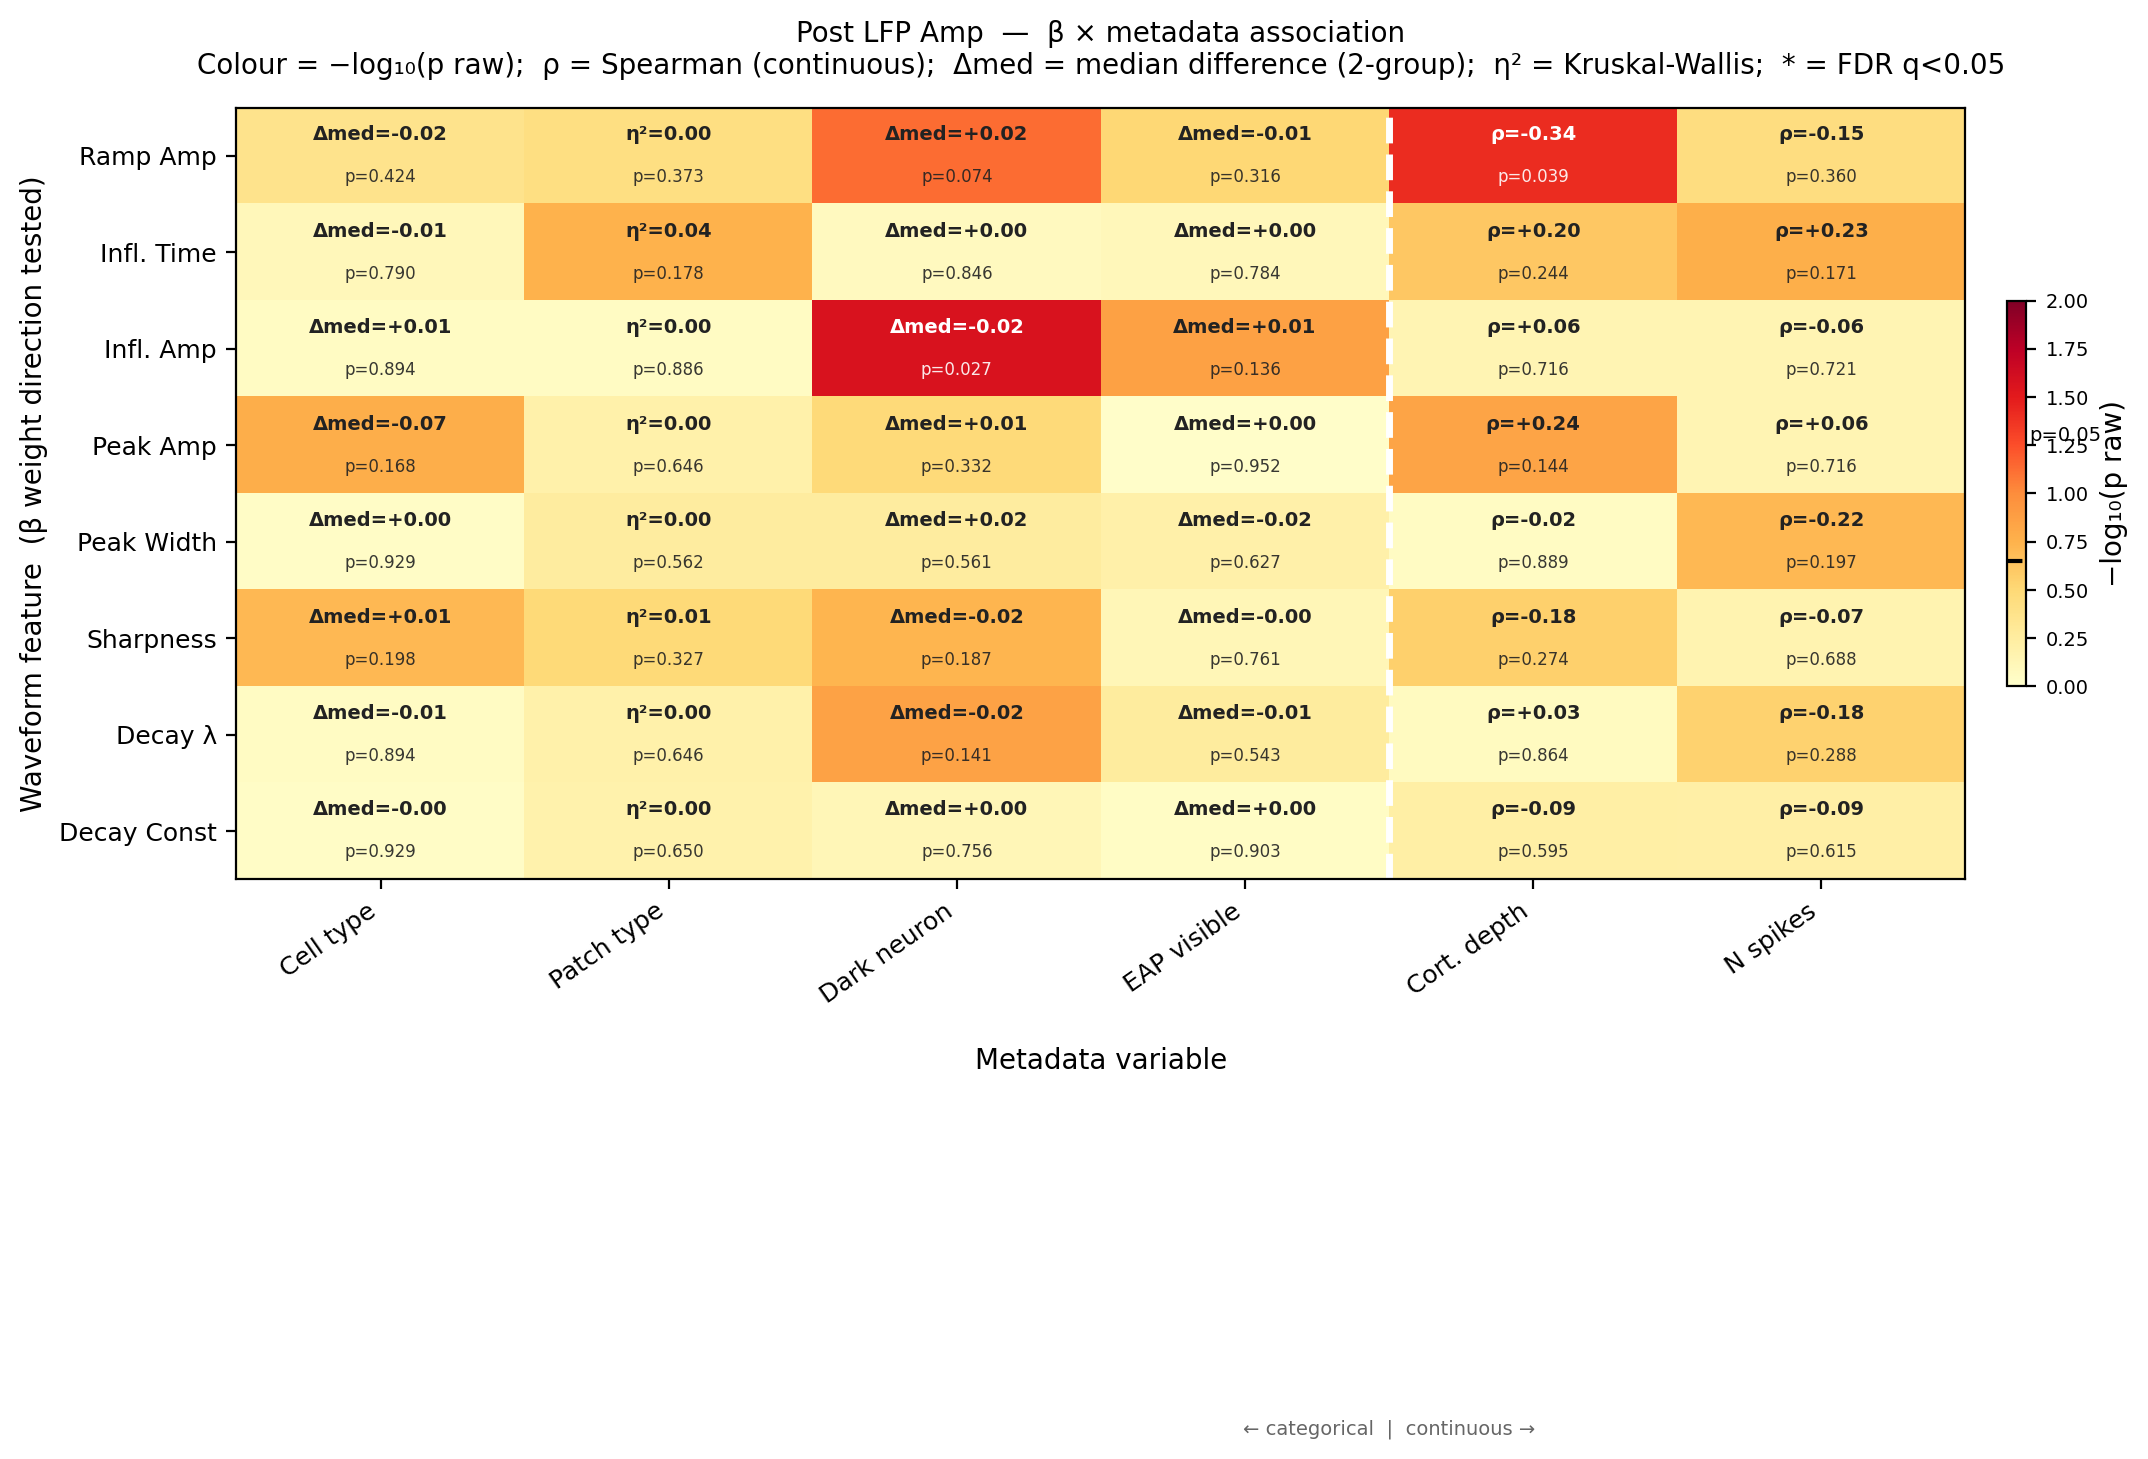

  Post LFP Amp:  FDR-sig = 0  |  nominally sig (p<0.05) = 2  |  showing top 6 by raw p

  Feature           Metadata            Effect    p-raw    FDR q  sig
  ─────────────────────────────────────────────────────────────────
  Infl. Amp         Dark neuron     Δmed = -0.020   0.0271   0.7905  *
  Ramp Amp          Cort. depth       ρ = -0.341   0.0388   0.7905  *
  Ramp Amp          Dark neuron     Δmed = +0.015   0.0745   0.7905  ns
  Infl. Amp         EAP visible     Δmed = +0.010   0.1365   0.7905  ns
  Decay λ           Dark neuron     Δmed = -0.021   0.1406   0.7905  ns
  Peak Amp          Cort. depth       ρ = +0.245   0.1444   0.7905  ns



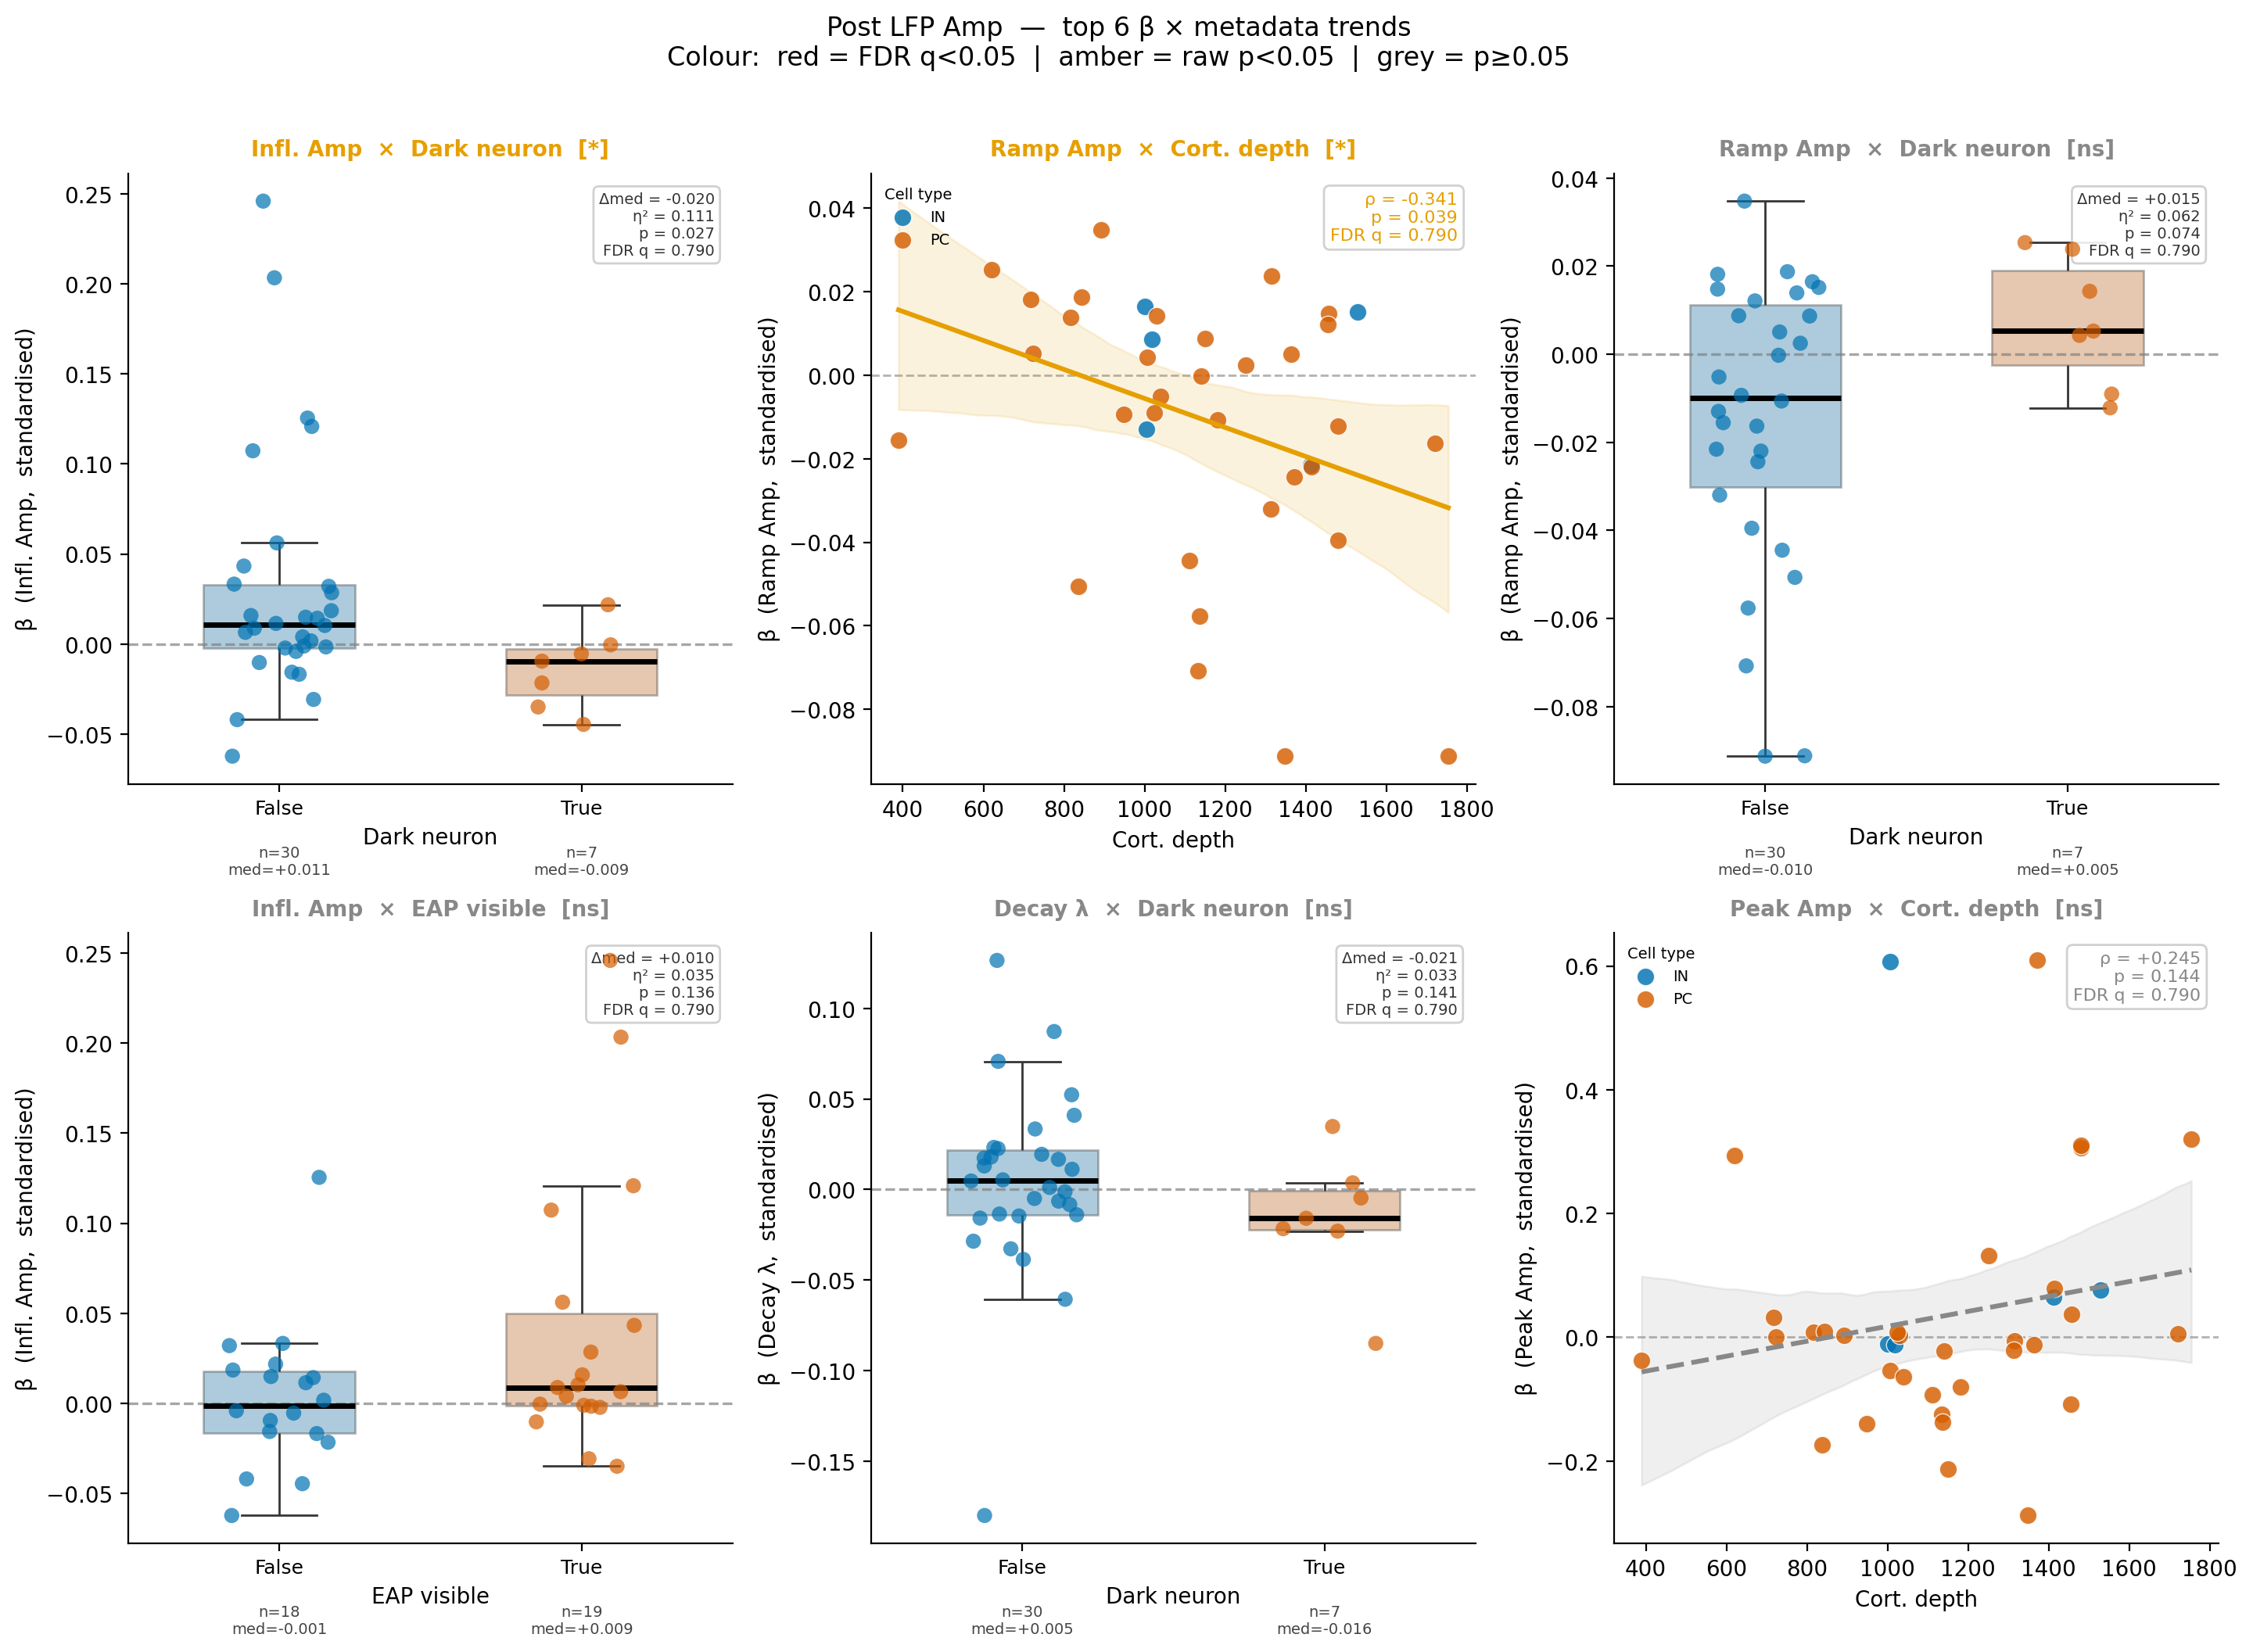

In [10]:
run_beta_metadata_analysis(beta_pop, df_r2, df, target_names, target_labels)

## 6. For R²-significant targets: does cell metadata explain beta weight direction?

Kruskal-Wallis (categorical) or Spearman ρ (continuous). FDR-corrected (BH) within each target. Top-6 pairs by raw p always shown so trends are visible at n=37.

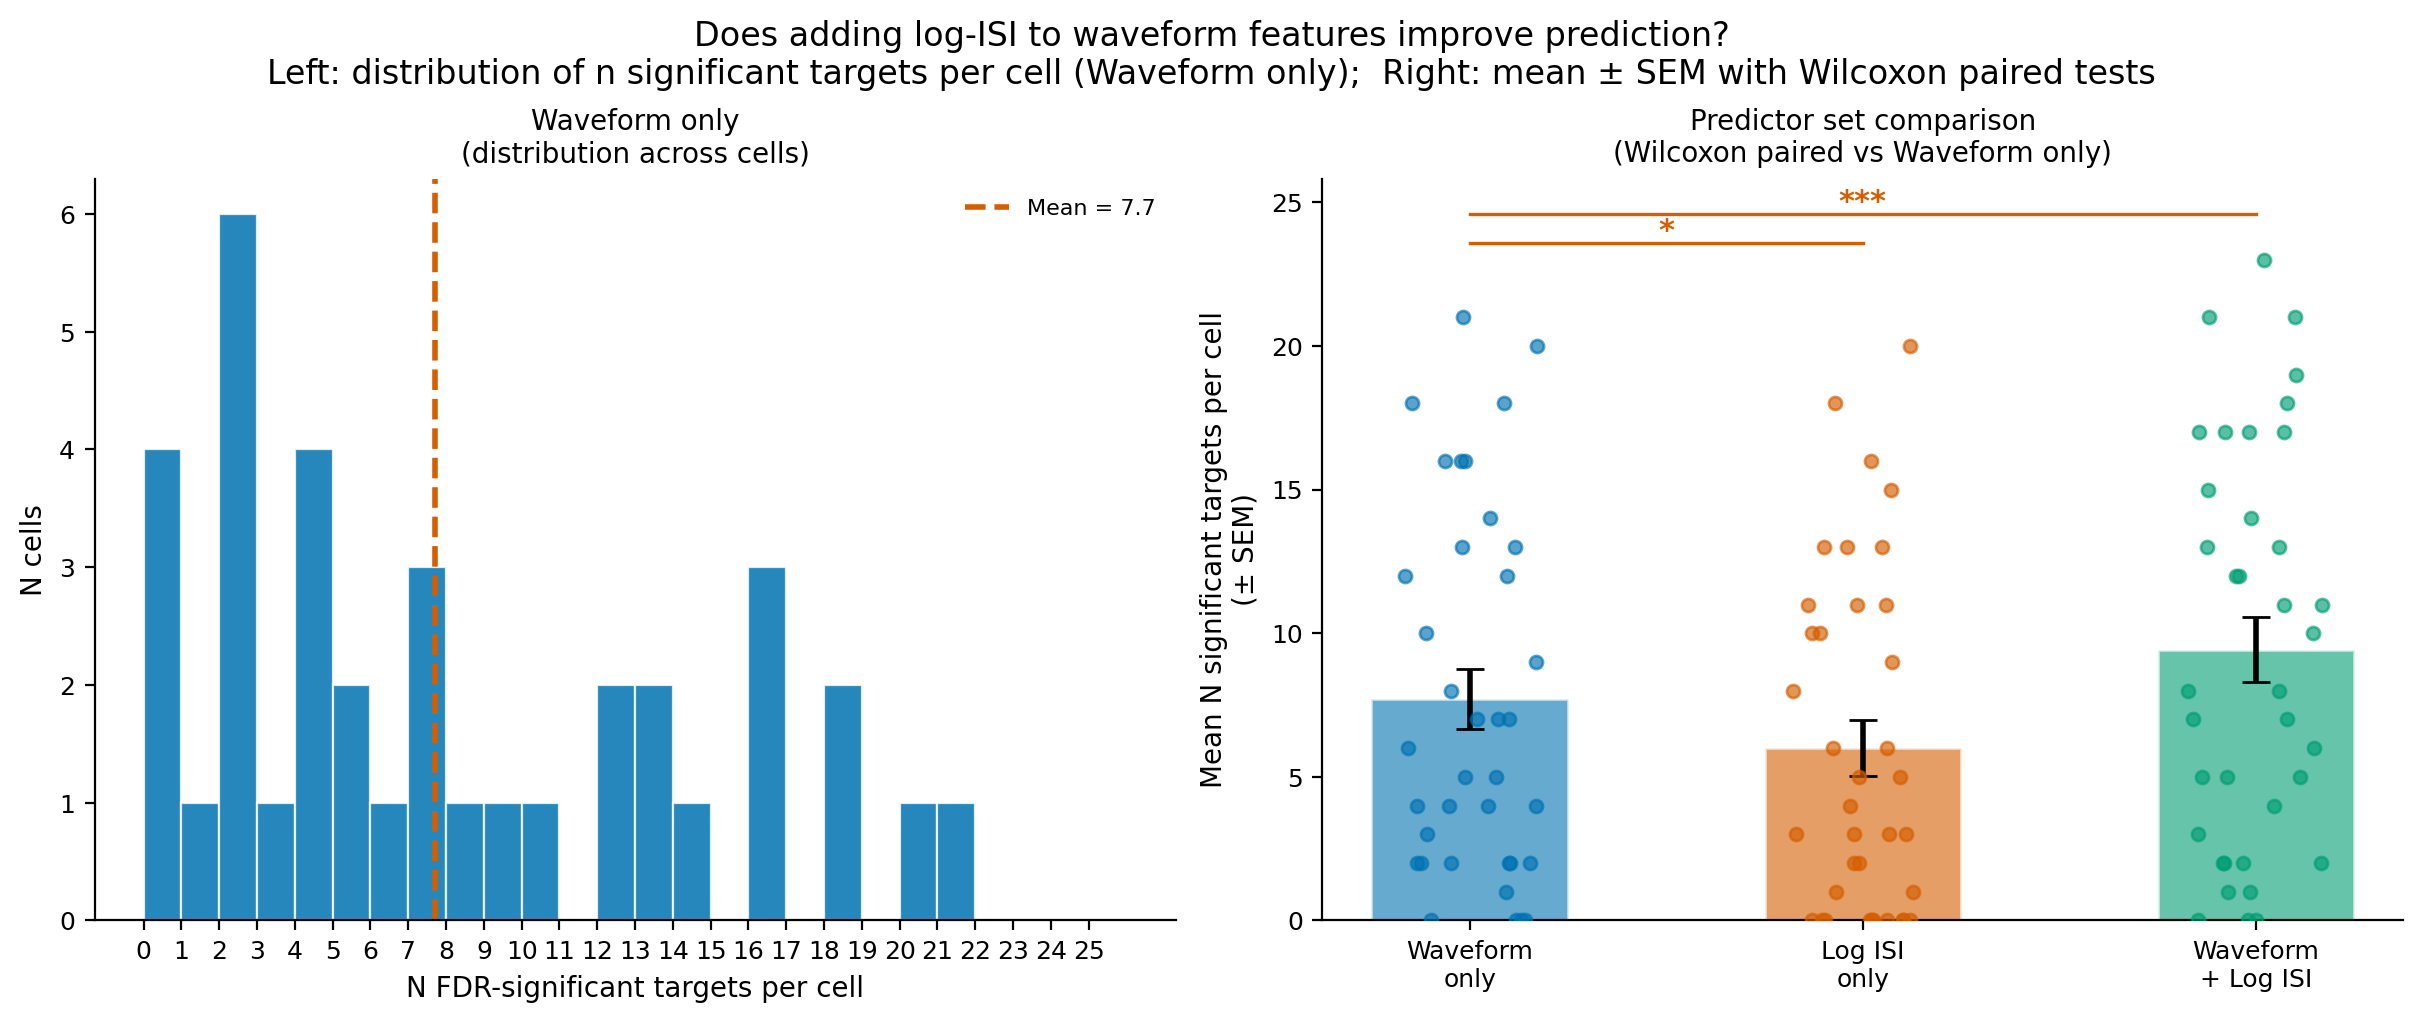

In [11]:
plot_predictor_set_comparison(df, predictor_sets)

## 7. Does adding log-ISI improve prediction?

Wilcoxon paired tests comparing n significant targets per cell across predictor sets.